# Cell Cycles Trajectory Inference

This notebook provides tutorial in trajectory inference in cell cycles using Curly Flow Matching on the human fibroblast data. For inference and higher dimensions please refer to $\texttt{src/models/deepcycle.py}$

For pre-processing data and dataset visualizations, please see [pre-processing notebook](cells_data.ipynb)

In [8]:
!hostnamectl

UnboundLocalError: local variable 'child' referenced before assignment

In [ ]:
# load in necessary packages
import math
import sys, os
import time

sys.path.append(os.path.abspath("..")) 

import scanpy as sc
import scvelo as scv

import torch

import matplotlib.pyplot as plt
import numpy as np
import ot as pot
import torch
import torchdyn
from torchdyn.core import NeuralODE
from torchdyn.datasets import generate_moons
import torchcfm
from torchcfm.utils import *
from sklearn.datasets import make_circles
from torchcfm.optimal_transport import OTPlanSampler
from src.models.components.single_marginal_utils import *
from src.models.components.mlp import * 


# Curly Flow Matching 

In [ ]:
# set seed
torch.manual_seed(0)
np.random.seed(0)

## Load Data

In [ ]:
# Load data
import scanpy as sc
adata_path = "/projects/bgdb/asachan/datasets/curl-fm/fibroblast_velocity.h5ad"
adata = sc.read_h5ad(adata_path)
X = torch.from_numpy(adata.obsm["X_umap"])
v_x, v_y = get_cell_velocities(adata)
V = torch.stack([v_x, v_y], dim=1)


In [ ]:
# Hyperparameters and models
w2s = []
time_list = []

# Model Training 

1000: loss 0.569 time 22.44
2000: loss 0.371 time 41.49
3000: loss 0.237 time 60.50
4000: loss 0.276 time 79.50
5000: loss 0.318 time 98.53
6000: loss 0.315 time 117.52
7000: loss 0.235 time 136.48
8000: loss 0.390 time 155.50
9000: loss 0.304 time 174.57
10000: loss 0.267 time 193.65


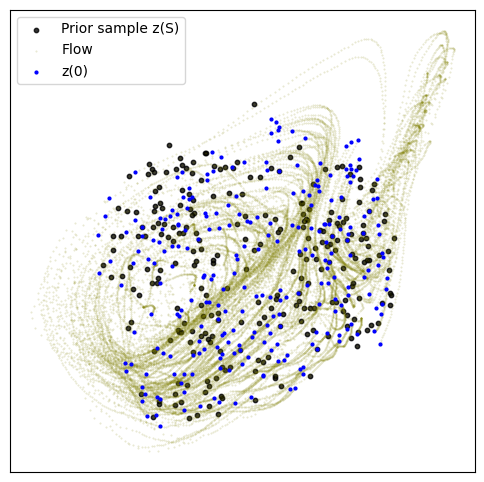

In [ ]:
# Algorithm 1
sigma = 0.01
dim = 2
batch_size = 256
alpha = 0.01
interpolant_net = MLP(dim=2*dim, out_dim=dim, time_varying=True)
optimizer_int = torch.optim.Adam(list(interpolant_net.parameters()))
start = time.time()

# Training loop for psi_t and xt_dot
for k in range(10000):
    optimizer_int.zero_grad()
    x0 = X[torch.randperm(X.shape[0], device=X.device)[:batch_size]]
    x1 = X[torch.randperm(X.shape[0], device=X.device)[:batch_size]]
    t = torch.rand(x0.shape[0]).type_as(x0)
    xt, mu_t_dot, eps = get_xt_xt_dot(t, x0, x1, interpolant_net, sigma = sigma)
    ut = get_u_xt(xt, X, V)
    cosine_loss = 1 - torch.nn.functional.cosine_similarity(ut, mu_t_dot).mean()
    l2_loss = torch.mean((ut - alpha*mu_t_dot) ** 2)
    loss = cosine_loss + l2_loss
    loss.backward()
    optimizer_int.step()
    traj = []
    if (k + 1) % 1000 == 0:
        end = time.time()
        print(f"{k+1}: loss {loss.item():0.3f} time {(end - start):0.2f}")

with torch.no_grad():
    for t in torch.linspace(0, 1, 100): 
        t = t.type_as(x0).repeat(x0.shape[0])
        t = t[:,None]
        xt_traj = get_xt(t, x0, x1, interpolant_net)[1]
        traj.append(xt_traj)

traj = torch.stack(traj)
plot_trajectories(traj.cpu().numpy())

In [ ]:
# Algorithm 2
model = MLP(dim=dim, out_dim=dim, time_varying=True)
optimizer_velocity = torch.optim.Adam(list(model.parameters()))
for k in range(2000):
    optimizer_velocity.zero_grad()
    x0 = X[torch.randperm(X.shape[0], device=X.device)[:batch_size]]
    x1 = X[torch.randperm(X.shape[0], device=X.device)[:batch_size]]
    x0, x1 = coupling(x0, x1, x0.shape[0], X, V, interpolant_net, sigma=sigma)
    t = torch.rand(x0.shape[0]).type_as(x0)
    xt, mu_t_dot, eps = get_xt_xt_dot(t, x0, x1, interpolant_net, sigma=sigma)
    vt = model(torch.cat([xt.detach(), t[:, None]], dim=-1))
    loss = torch.mean((vt - mu_t_dot.detach()) ** 2)
    loss.backward()
    optimizer_velocity.step()
    time_list.append(k)
    if (k + 1) % 1000 == 0:
        end = time.time()
        print(f"{k+1}: loss {loss.item():0.3f} time {(end - start):0.2f}")
        start = end
    
node = NeuralODE(
    torch_wrapper(model), solver="euler", sensitivity="adjoint", atol=1e-4, rtol=1e-4
)
with torch.no_grad():
    traj = node.trajectory(
        x0,
        t_span=torch.linspace(0, 1, 100),
    )
    if (k + 1) % 10000 == 0:
        torch.save(traj, f"traj_{k}.pt")
    plot_trajectories(traj.cpu().numpy())

w2 = torchcfm.optimal_transport.wasserstein(traj[-1], x1)
w2s.append(w2)
print(f"{k+1}: loss {loss.item():0.3f} time {(end - start):0.2f} w2 {w2:0.3f}")
start = end

1000: loss 109.896 time 2851.37


KeyboardInterrupt: 